# Project Overview

This project aims to develop a machine learning model to predict the presence of **diabetes** based on key medical indicators.

## Objectives
- Understand relationships between patient features and diabetes status.
- Preprocess and explore the dataset to uncover insights.
- Train and evaluate a predictive model using **XGBoost**.
- Address challenges like **class imbalance** and optimize model performance.

## Dataset Features
- Demographics: `age`, `gender`, `smoking_history`
- Medical Indicators: `bmi`, `HbA1c_level`, `blood_glucose_level`, `hypertension`, `heart_disease`


## Dataset Source & Credits

This project uses the [Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset) available on Kaggle, provided by [Mustafa Tariq](https://www.kaggle.com/iammustafatz).

**Dataset Description:**
The dataset includes medical attributes such as age, BMI, blood glucose levels, HbA1c levels, and other patient information useful for predicting diabetes diagnoses.

All rights and credit for the dataset belong to the original creator. The dataset is made available under the terms specified on its [Kaggle page](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset).


# Imports

This section includes all necessary libraries for:
- Data manipulation
- Visualization
- Model training and evaluation
- Imbalance handling and scaling


In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay,
    brier_score_loss
)

## Global Settings

In [2]:
sns.set_theme(style='whitegrid', context='notebook', palette='Set2')
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

warnings.filterwarnings("ignore", "use_inf_as_na")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Preprocessing

Before training a model, we clean and prepare the dataset to ensure it is in optimal shape.

### Key Steps:
- Handle missing values and typos
- Normalize smoking history into clear categories
- Encode categorical features like `gender`
- Scale numeric features where appropriate
- Handle class imbalance in the target variable


In [3]:
df = pd.read_csv('data/diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


## Dataset Overview

This section shows the structure of the dataset, including data types, non-null counts, and basic statistics. We also check the class distribution of the target variable `diabetes` to confirm any imbalance.

In [4]:
df.info()
df.describe()
df['diabetes'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

### Smoking Normalization

The smoking variable has a few values that can be grouped, so we identify and clean them below

In [5]:
df['smoking_history'].value_counts(dropna=False)

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [6]:
smoking_map = {
    'never': 'none',
    'ever': 'none',
    'former': 'past',
    'not current': 'past',
    'current': 'present',
}

def normalize_smoking(val):
    val = str(val).strip().lower()
    for key in smoking_map:
        if key in val:
            return smoking_map[key]
    return 'unknown'

df['smoking_history'] = df['smoking_history'].apply(normalize_smoking)

In [7]:
df = df[df['gender'].str.lower() != 'other']
df['gender'] = df['gender'].str.lower()
df['gender'] = df['gender'].map({'male': 0, 'female': 1})

In [8]:
df_eda = df.copy()
df = pd.get_dummies(
    df,
    columns=['smoking_history'],
    drop_first=True
)

In [9]:
scaler = StandardScaler()
scaled_features = [
    'age', 'bmi', 'HbA1c_level', 'blood_glucose_level'
]
df_scaled = df.copy()
df_scaled[scaled_features] = scaler.fit_transform(df[scaled_features])

### After processing, our dataset and scaled dataset are as follows:

In [10]:
df.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_past,smoking_history_present,smoking_history_unknown
0,1,80.0,0,1,25.19,6.6,140,0,False,False,False
1,1,54.0,0,0,27.32,6.6,80,0,False,False,True
2,0,28.0,0,0,27.32,5.7,158,0,False,False,False
3,1,36.0,0,0,23.45,5.0,155,0,False,True,False
4,0,76.0,1,1,20.14,4.8,155,0,False,True,False


In [11]:
df_scaled.head()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_past,smoking_history_present,smoking_history_unknown
0,1,1.692577,0,1,-0.321051,1.001692,0.047709,0,False,False,False
1,1,0.537899,0,0,-0.000114,1.001692,-1.426157,0,False,False,True
2,0,-0.616779,0,0,-0.000114,0.161089,0.489869,0,False,False,False
3,1,-0.261494,0,0,-0.583225,-0.492714,0.416175,0,False,True,False
4,0,1.514935,1,1,-1.081957,-0.679515,0.416175,0,False,True,False


# Exploratory Data Analysis (EDA)

This section explores the dataset to understand patterns, relationships, and potential predictors of diabetes.

### Analysis Includes:
- Dataset summary and class balance
- Distribution of numeric and categorical features
- Relationship between features and target (`diabetes`)
- Correlation matrix to detect multicollinearity


## Diabetes Class Distribution

This plot visualizes the number of diabetic vs non-diabetic cases. It helps confirm class imbalance and prepares us for how it may impact modeling.

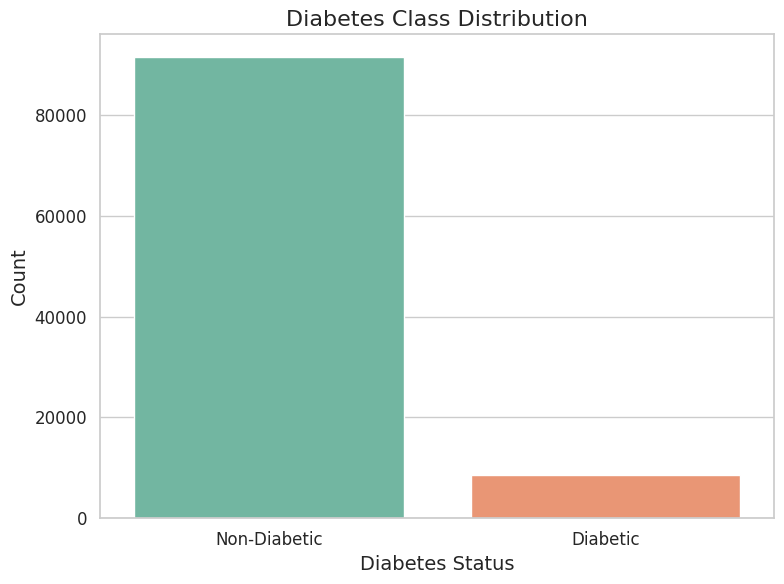

In [12]:
# Diabetes Class Distribution
fig, ax = plt.subplots()
sns.countplot(x='diabetes', data=df, ax=ax)
ax.set_title('Diabetes Class Distribution')
ax.set_xlabel('Diabetes Status')
ax.set_ylabel('Count')
ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])
plt.tight_layout()
plt.show()


## Distribution of Continuous Features

We plot histograms with KDE curves for key numeric features to understand their distributions. This helps detect skewness, outliers, or transformation needs.

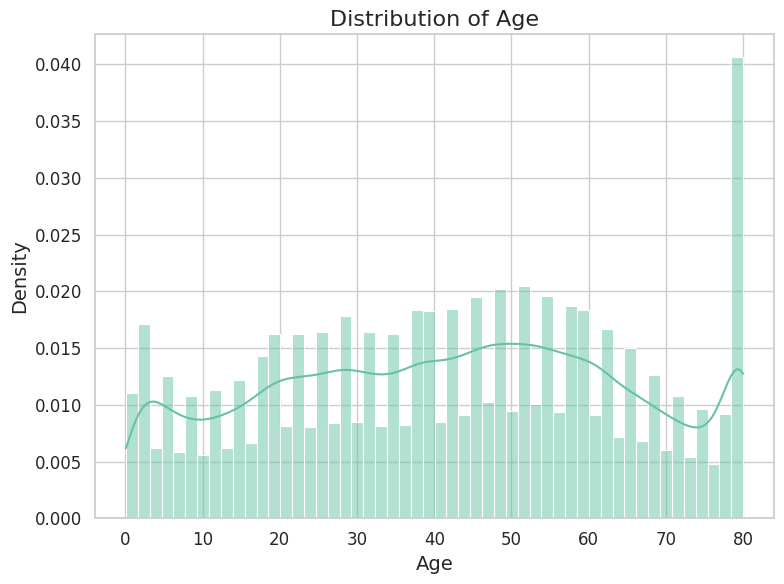

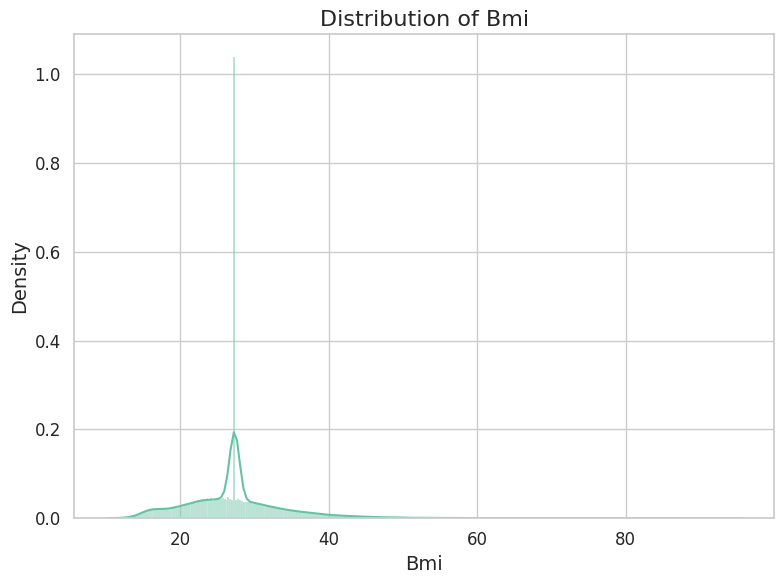

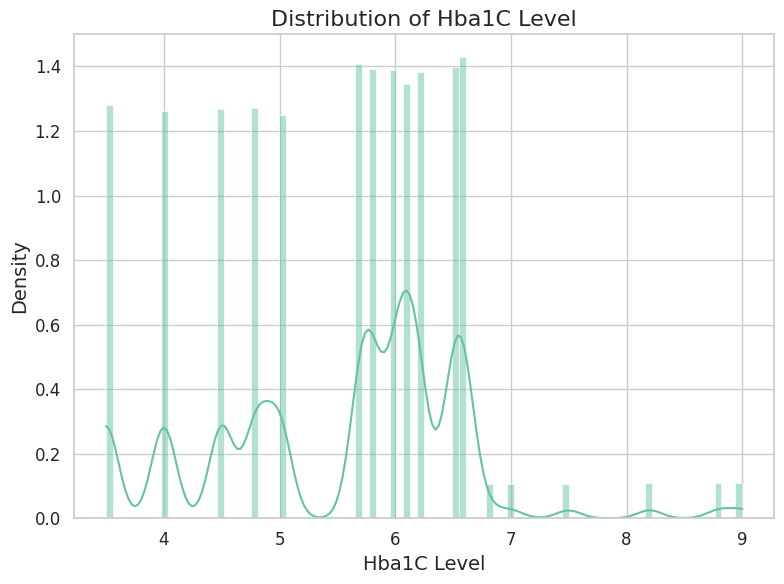

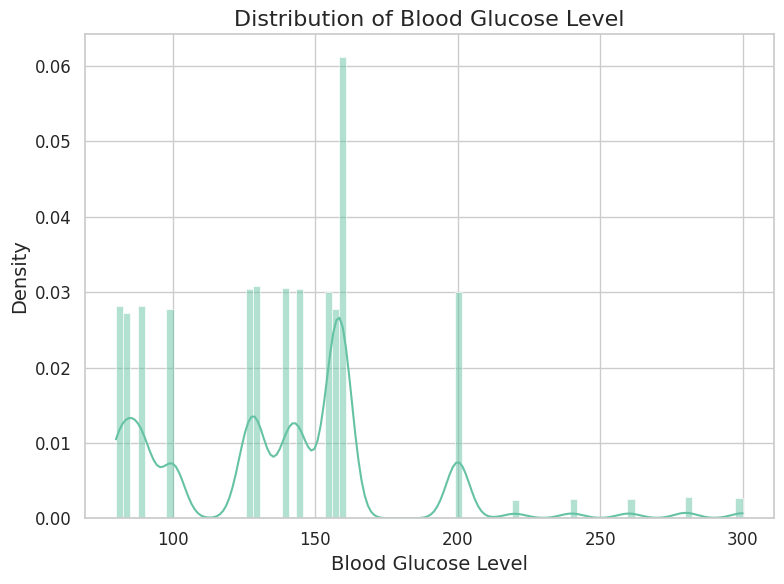

In [13]:
# Numerical Feature Distributions
num_feats = [
    'age', 'bmi', 'HbA1c_level', 'blood_glucose_level'
]
for feat in num_feats:
    fig, ax = plt.subplots()
    sns.histplot(df[feat], kde=True, stat='density', ax=ax)
    ax.set_title(f'Distribution of {feat.replace("_", " ").title()}')
    ax.set_xlabel(feat.replace('_', ' ').title())
    ax.set_ylabel('Density')
    plt.tight_layout()
    plt.show()


## Categorical Feature Distributions

These plots explore the distribution of categorical features like gender and smoking history to identify class representation and potential biases.

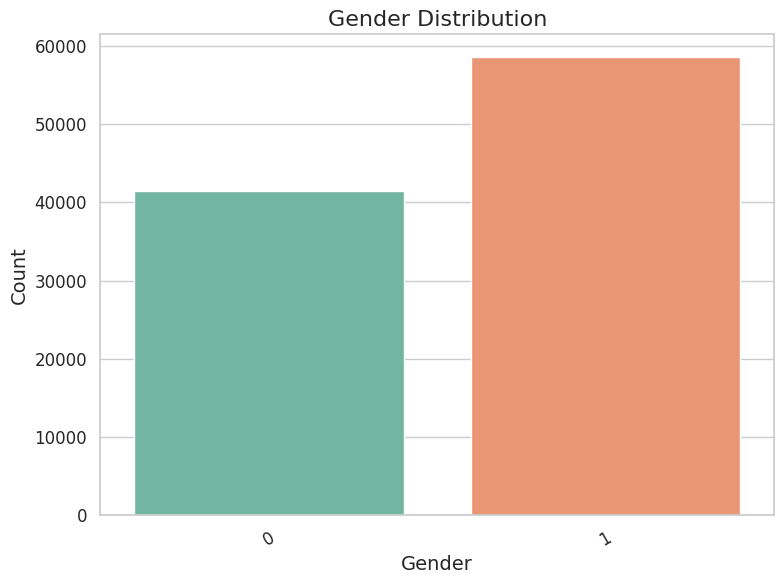

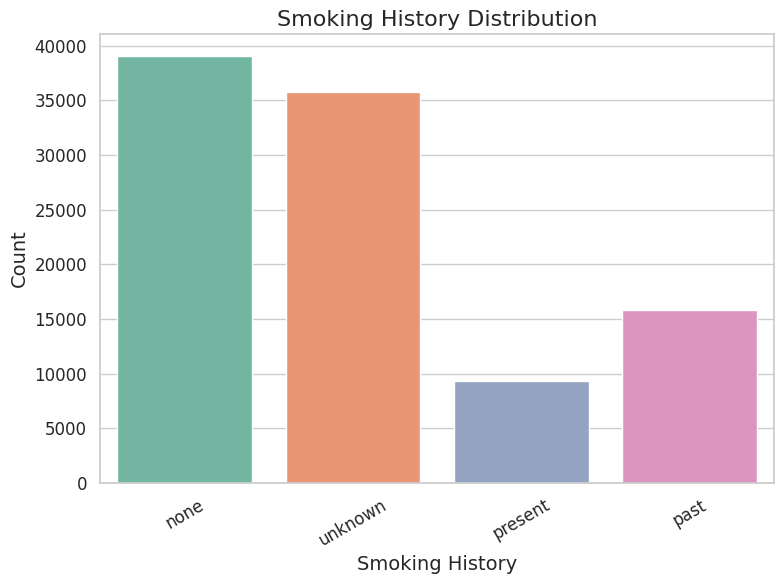

In [14]:
# Categorical Feature Distributions
for col, title in [
    ('gender',            'Gender Distribution'),
    ('smoking_history',   'Smoking History Distribution'),
]:
    fig, ax = plt.subplots()
    sns.countplot(x=col, data=df_eda, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col.replace('_',' ').title())
    ax.set_ylabel('Count')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## Diabetes Rate by Categorical Features

We analyze how the likelihood of diabetes varies across gender, hypertension, and heart disease. This can uncover important risk factors.

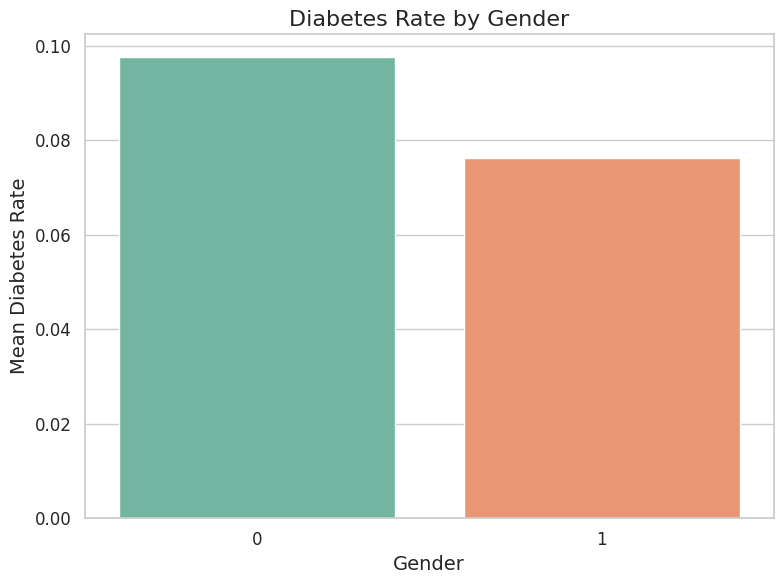

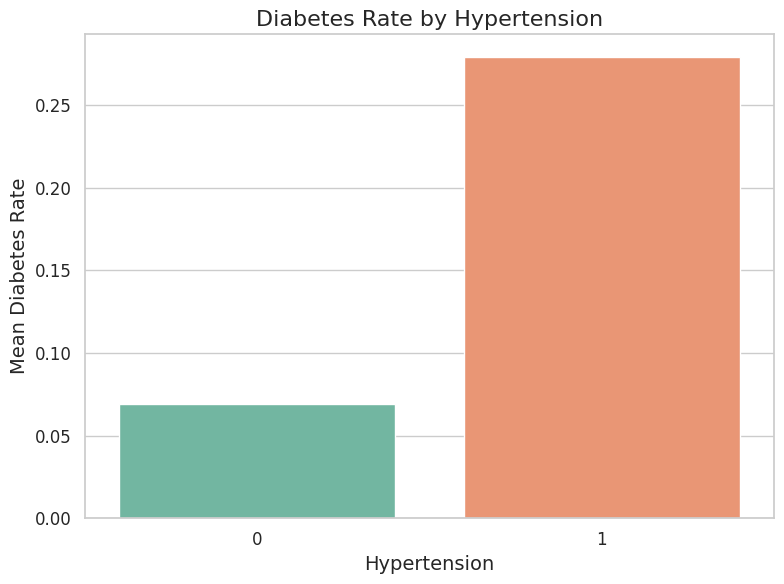

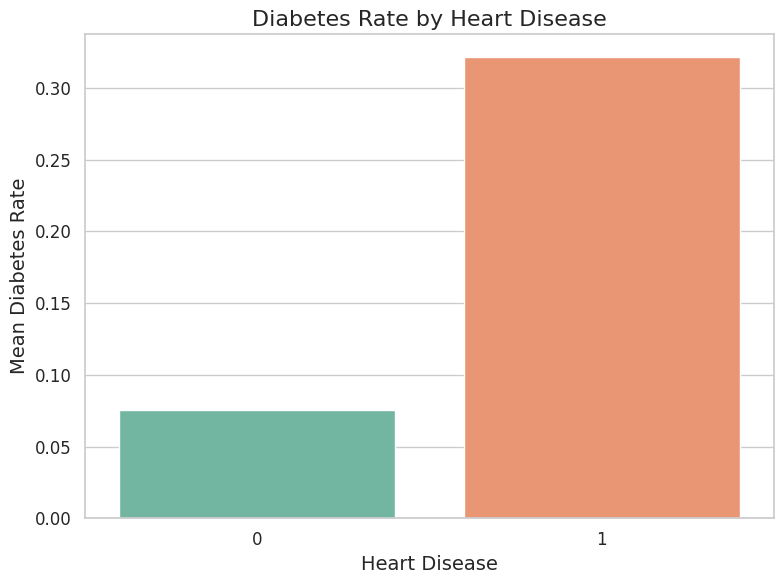

In [15]:
# Diabetes Rate by Key Categorical Features
for col in ['gender', 'hypertension', 'heart_disease']:
    fig, ax = plt.subplots()
    sns.barplot(x=col, y='diabetes', data=df, ax=ax, ci=None)
    ax.set_title(f'Diabetes Rate by {col.replace("_"," ").title()}')
    ax.set_xlabel(col.replace('_',' ').title())
    ax.set_ylabel('Mean Diabetes Rate')
    plt.tight_layout()
    plt.show()


## Boxplots of Continuous Features vs Diabetes

Boxplots allow us to compare the distributions of key numeric variables between diabetic and non-diabetic groups, identifying differences in medians and outliers.

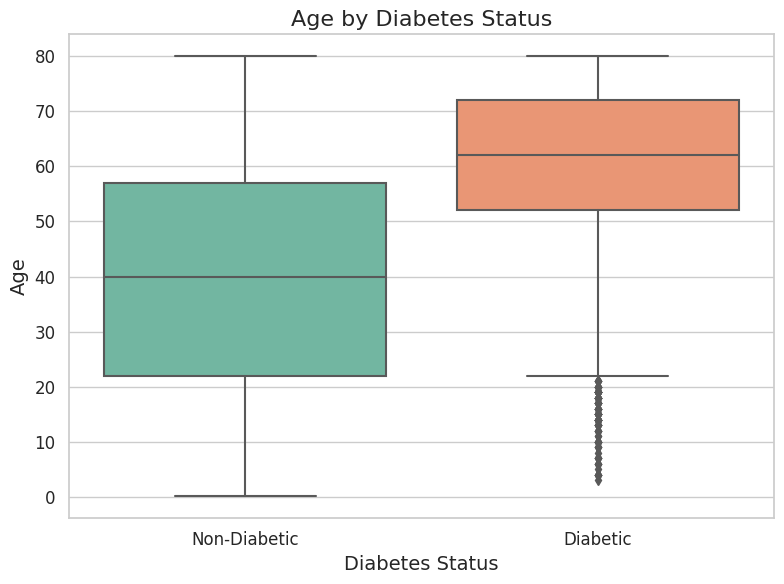

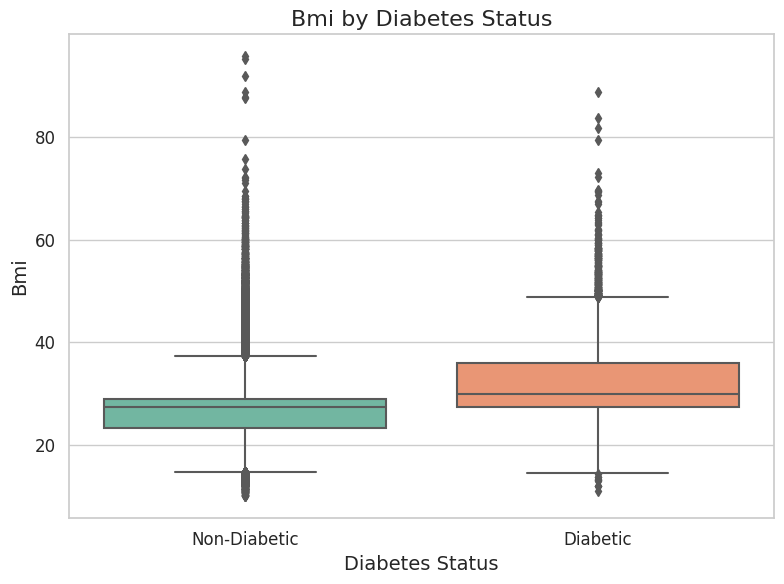

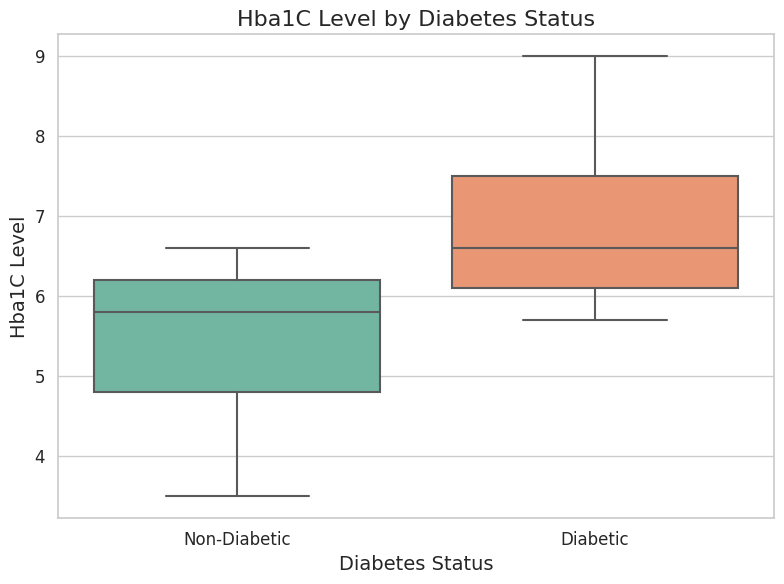

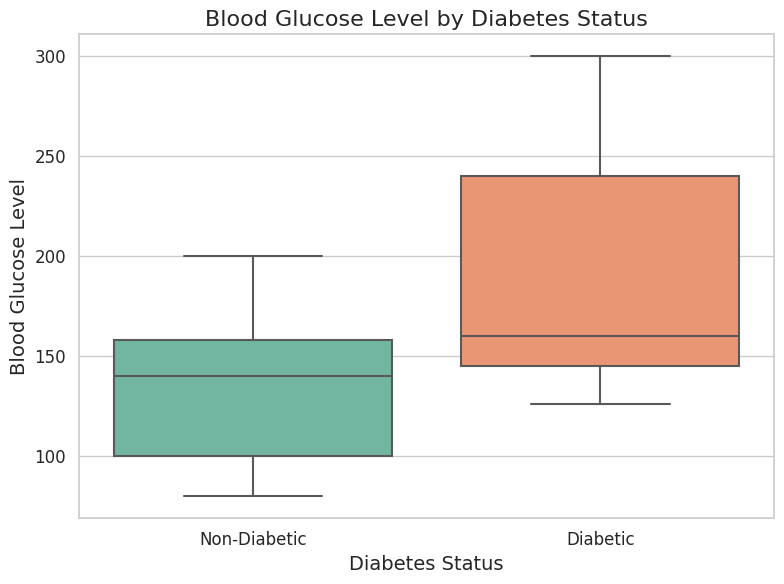

In [16]:
# Boxplots: Continuous vs. Diabetes
for feat in ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']:
    fig, ax = plt.subplots()
    sns.boxplot(x='diabetes', y=feat, data=df, ax=ax)
    ax.set_title(f'{feat.replace("_"," ").title()} by Diabetes Status')
    ax.set_xlabel('Diabetes Status')
    ax.set_ylabel(feat.replace('_',' ').title())
    ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])
    plt.tight_layout()
    plt.show()


## Correlation Heatmap

This heatmap shows linear relationships between all numerical features. High correlations might indicate redundancy or strong predictors of diabetes.

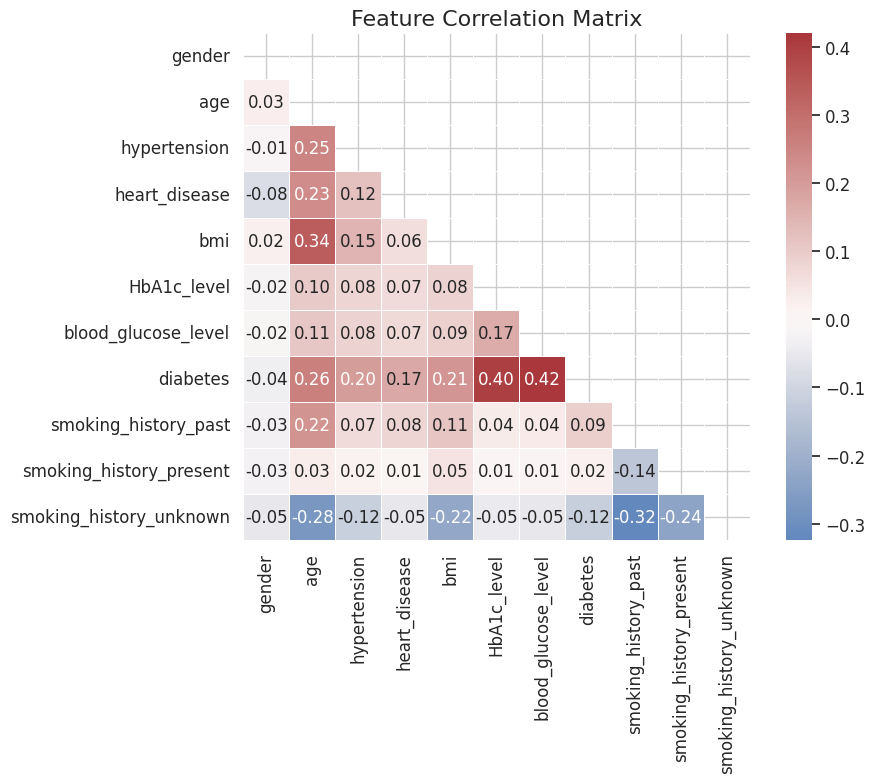

In [17]:
# Correlation Heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='vlag', center=0, square=True, linewidths=.5, ax=ax
)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Model Training

We train an XGBoost classifier to predict diabetes based on the preprocessed features.

### Highlights:
- Train/test split to evaluate generalization
- Use of `scale_pos_weight` to handle class imbalance
- Monitoring metrics like AUC during training


## Training Split and Weights

Here we split the data into train and test sets and determine weights for offsetting the class imbalance.

In [18]:
X = df_scaled.drop('diabetes', axis=1)
y = df_scaled['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos
print(scale_pos_weight)

10.7625


## Training

We train the model using the weights we determined previously and some basic hyperparameters.

In [19]:
base_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

base_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

# Model Evaluation

We evaluate model performance using classification metrics beyond accuracy due to class imbalance.

### Metrics Used:
- Confusion matrix
- Precision, Recall, F1-Score
- ROC-AUC and Precision-Recall AUC
- Visualizations: ROC curve, PR curve


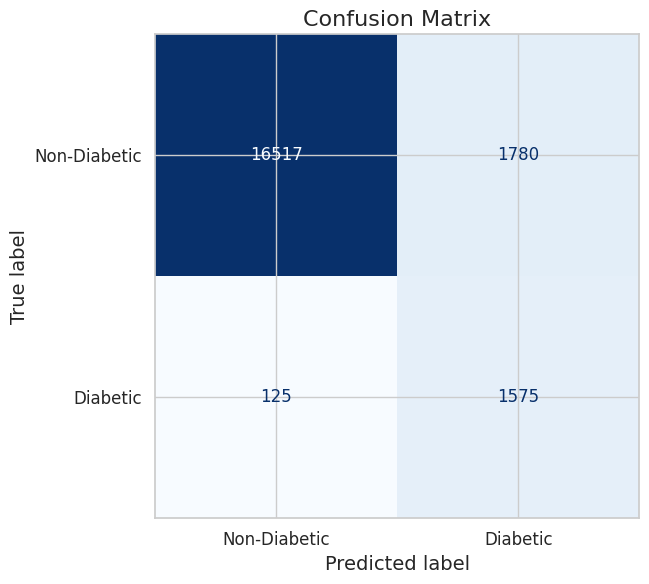

Classification Report:
              precision    recall  f1-score   support

           0     0.9925    0.9027    0.9455     18297
           1     0.4694    0.9265    0.6231      1700

    accuracy                         0.9047     19997
   macro avg     0.7310    0.9146    0.7843     19997
weighted avg     0.9480    0.9047    0.9181     19997

ROC-AUC Score: 0.9796
Precision-Recall AUC: 0.8870
Brier Score Loss (calibration): 0.0585


In [20]:
y_pred = base_model.predict(X_test)
y_proba = base_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=base_model.classes_)
fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic','Diabetic'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

pr_auc = average_precision_score(y_test, y_proba)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

brier = brier_score_loss(y_test, y_proba)
print(f"Brier Score Loss (calibration): {brier:.4f}")

## Visualizations

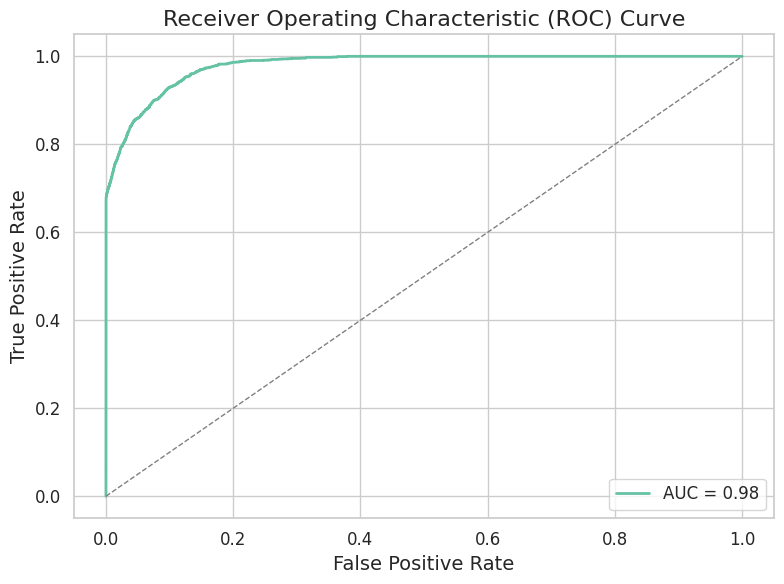

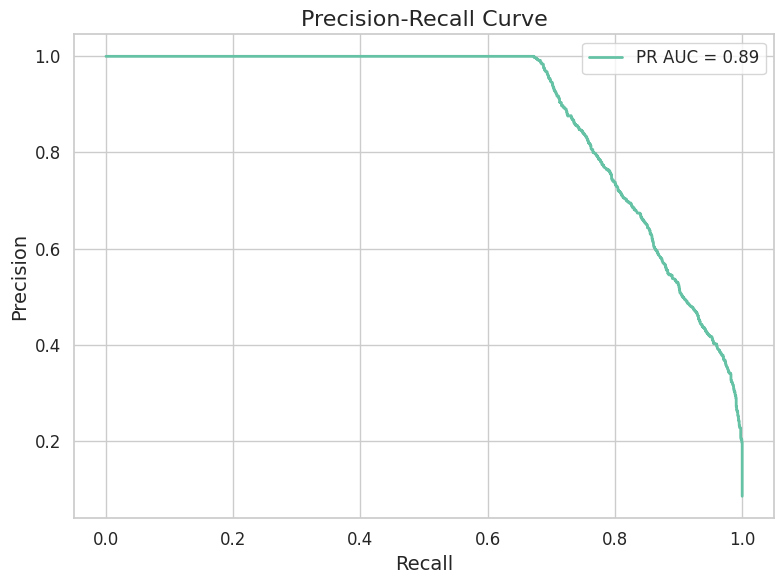

In [21]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig, ax = plt.subplots()
ax.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', linewidth=2)
ax.plot([0,1],[0,1], linestyle='--', linewidth=1, color='gray')
ax.set_title('Receiver Operating Characteristic (ROC) Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots()
ax.plot(recall, precision, label=f'PR AUC = {pr_auc:.2f}', linewidth=2)
ax.set_title('Precision-Recall Curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='upper right')
ax.grid(True)
plt.tight_layout()
plt.show()

## Initial Conclusions

Before tuning, the model has high recall but low precision. This indicates that the model is identifying most of the cases of diabetes, but also incorrectly labeling non-cases as diabetes.

# Hyperparameter Tuning

To improve performance, we perform hyperparameter optimization using grid search or randomized search.

### Example Parameters:
- `max_depth`
- `learning_rate`
- `n_estimators`
- `scale_pos_weight`
- Evaluation using cross-validation


In [22]:
base_estimator = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

param_dist = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(
    estimator=base_estimator,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)



print(f"Best ROC-AUC (CV): {random_search.best_score_:.4f}")
print("Best Hyperparameters:")
for param, value in random_search.best_params_.items():
    print(f"  • {param}: {value}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best ROC-AUC (CV): 0.9795
Best Hyperparameters:
  • subsample: 1.0
  • reg_lambda: 1
  • reg_alpha: 0.1
  • n_estimators: 200
  • min_child_weight: 3
  • max_depth: 3
  • learning_rate: 0.1
  • gamma: 0
  • colsample_bytree: 0.6


## Retraining Using Best Parameters

Once the best parameters are determined, we retrain the model with the new parameters.

In [23]:
best_params = random_search.best_params_
tuned_model = XGBClassifier(
    **best_params,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
tuned_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

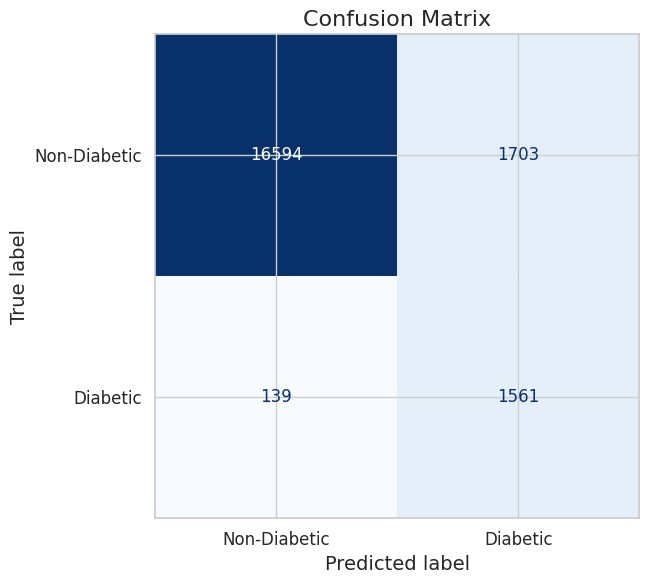

Classification Report:
              precision    recall  f1-score   support

           0     0.9917    0.9069    0.9474     18297
           1     0.4782    0.9182    0.6289      1700

    accuracy                         0.9079     19997
   macro avg     0.7350    0.9126    0.7882     19997
weighted avg     0.9480    0.9079    0.9203     19997

ROC-AUC Score: 0.9799
Precision-Recall AUC: 0.8877
Brier Score Loss (calibration): 0.0581


In [24]:
y_pred = tuned_model.predict(X_test)
y_proba = tuned_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=tuned_model.classes_)
fig, ax = plt.subplots()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Diabetic','Diabetic'])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

pr_auc = average_precision_score(y_test, y_proba)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

brier = brier_score_loss(y_test, y_proba)
print(f"Brier Score Loss (calibration): {brier:.4f}")

# Conclusion

## Summary of Results

### Baseline Model  
- **Accuracy:** 90.47%  
- **ROC-AUC:** 0.9796  
- **PR-AUC:** 0.8870  
- **Brier Score:** 0.0585  

| Class | Precision | Recall  | F1-Score | Support |
|:-----:|:---------:|:-------:|:--------:|:-------:|
| **0** | 0.9925    | 0.9027  | 0.9455   | 18,297  |
| **1** | 0.4694    | 0.9265  | 0.6231   | 1,700   |

> The baseline XGBoost model achieves excellent discrimination (ROC-AUC 0.9796) and strong sensitivity for diabetics (Recall = 92.65%), but at the cost of lower precision (46.94%)—resulting in many false positives.

---

### Tuned Model  
- **Accuracy:** 90.79% (+0.32%)  
- **ROC-AUC:** 0.9799 (+0.0003)  
- **PR-AUC:** 0.8877 (+0.0007)  
- **Brier Score:** 0.0581 (–0.0004)  

| Class | Precision | Recall  | F1-Score | Support |
|:-----:|:---------:|:-------:|:--------:|:-------:|
| **0** | 0.9917    | 0.9069  | 0.9474   | 18,297  |
| **1** | 0.4782    | 0.9182  | 0.6289   | 1,700   |

> After hyperparameter tuning, the model shows modest gains: slightly higher overall accuracy, marginally better AUCs, and improved balance for the diabetic class (Precision +0.87 pp, F1 +0.58 pp).

---

## Key Takeaways

- **High Sensitivity Maintained:** Both models catch over 91% of actual diabetics, aligning with the goal to minimize missed cases.  
- **Precision Gains:** Tuning improved positive-class precision from 46.94% to 47.82%, reducing false positives slightly.  
- **Well-Calibrated Probabilities:** Brier Score decreased, indicating more reliable probability estimates post-tuning.  
- **Diminishing Returns:** In a high-dimensional search, further tuning yields small incremental gains; consider cost–benefit of additional search.

---

## Next Steps

1. **Threshold Optimization**  
   - Use the Precision-Recall curve to select an operating point that better balances precision vs. recall for your clinical setting.

2. **Probability Calibration**  
   - Apply Platt scaling or isotonic regression to refine predicted probabilities and further lower Brier Score.

3. **Explainability**  
   - Leverage SHAP or LIME to identify which features (e.g., HbA1c, glucose level) drive predictions, aiding clinician trust.

4. **Alternative Sampling & Models**  
   - Experiment with SMOTE/ADASYN or other algorithms (LightGBM, CatBoost) to see if precision can be improved without sacrificing recall.

5. **External Validation**  
   - Test the tuned model on an independent cohort or through a prospective study to confirm robustness and generalizability.
  
---

## GitHub Repo

### Link: https://github.com/Jin-yah/diabetes-predictor-xgb
